# Data Science Homework – Air Quality & Weather Analysis for NYC

**Period:** June–December 2024  
**Goal:** Collect, clean, merge, and analyze air quality, weather, and traffic data for New York City, then forecast PM2.5 using time series models.

---

## Task 1 – Data Collection

We collect data from three sources:
1. **OpenWeather Air Pollution API** – PM2.5, PM10, NO2, O3 (requires API key stored in `.env`)
2. **Open-Meteo API** – temperature, humidity, wind speed, precipitation (free, no key needed)
3. **NYC Open Data – Traffic API** – hourly vehicle counts (free, no key needed)

Raw responses are saved to `data/raw/` as CSV files.

In [31]:
# ── Imports and environment setup ────────────────────────────────────────────
import os
import time
import requests
import pandas as pd
from datetime import datetime, timezone
from dotenv import load_dotenv

# Load OPENWEATHER_KEY from .env file in the project root
load_dotenv()

# Directory where raw CSV files will be saved
RAW_DIR = os.path.join('data', 'raw')
os.makedirs(RAW_DIR, exist_ok=True)

# NYC coordinates used in every API call
NYC_LAT = 40.7128
NYC_LON = -74.0060

print('Setup complete. RAW_DIR:', RAW_DIR)

Setup complete. RAW_DIR: data/raw


### 1.1 – Air Pollution API (Open-Meteo Air Quality)

Endpoint: `https://air-quality-api.open-meteo.com/v1/air-quality`

Open-Meteo Air Quality è **gratuita e non richiede API key**.  
Fornisce gli stessi inquinanti orari richiesti dall'homework: PM2.5, PM10, NO2, O3.  
L'intero periodo Giu–Dic 2024 viene scaricato in un'unica chiamata.

In [32]:
# ── 1.1  Air Pollution – Open-Meteo Air Quality API ──────────────────────────
# Free, no API key required. Provides hourly PM2.5, PM10, NO2, O3 for any location.

def fetch_air_quality_openmeteo(lat, lon, start_date, end_date):
    """
    Fetch hourly air quality data from Open-Meteo Air Quality API.

    Parameters
    ----------
    lat, lon     : float – location coordinates
    start_date   : str   – 'YYYY-MM-DD' (inclusive)
    end_date     : str   – 'YYYY-MM-DD' (inclusive)

    Returns
    -------
    pd.DataFrame with columns:
        datetime, pm2_5, pm10, nitrogen_dioxide, ozone
    """
    url = 'https://air-quality-api.open-meteo.com/v1/air-quality'
    params = {
        'latitude':   lat,
        'longitude':  lon,
        'hourly':     'pm2_5,pm10,nitrogen_dioxide,ozone',
        'start_date': start_date,
        'end_date':   end_date,
        'timezone':   'UTC',
    }
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    data = response.json()

    # API returns parallel arrays under data['hourly']
    hourly = data['hourly']
    df = pd.DataFrame({
        'datetime':         pd.to_datetime(hourly['time']),
        'pm2_5':            hourly['pm2_5'],
        'pm10':             hourly['pm10'],
        'nitrogen_dioxide': hourly['nitrogen_dioxide'],
        'ozone':            hourly['ozone'],
    })
    return df


print('Fetching air quality data from Open-Meteo …')
df_air = fetch_air_quality_openmeteo(
    lat        = NYC_LAT,
    lon        = NYC_LON,
    start_date = '2024-06-01',
    end_date   = '2024-12-31',
)

air_path = os.path.join(RAW_DIR, 'air_pollution_nyc.csv')
df_air.to_csv(air_path, index=False)

print(f'Saved {len(df_air)} rows → {air_path}')
df_air.head()

Fetching air quality data from Open-Meteo …
Saved 5136 rows → data/raw/air_pollution_nyc.csv


,datetime,pm2_5,pm10,nitrogen_dioxide,ozone
0,2024-06-01 00:00:00,9.1,13.0,27.5,45.0
1,2024-06-01 01:00:00,9.3,13.3,27.3,44.0
2,2024-06-01 02:00:00,8.9,12.7,26.8,42.0
3,2024-06-01 03:00:00,8.4,12.0,25.5,42.0
4,2024-06-01 04:00:00,7.8,11.1,22.5,44.0


### 1.2 – Open-Meteo Weather API

Open-Meteo provides free historical weather data with no API key required.  
We request **hourly** variables for the full Jun–Dec 2024 window in a single call:
- `temperature_2m` – air temperature at 2 m (°C)
- `relativehumidity_2m` – relative humidity at 2 m (%)
- `windspeed_10m` – wind speed at 10 m (km/h)
- `precipitation` – hourly precipitation (mm)

In [33]:
# ── 1.2  Weather – Open-Meteo ─────────────────────────────────────────────────

def fetch_openmeteo_weather(lat, lon, start_date, end_date):
    """
    Fetch hourly historical weather from the Open-Meteo archive API.

    Parameters
    ----------
    lat, lon     : float – location coordinates
    start_date   : str   – 'YYYY-MM-DD' (inclusive)
    end_date     : str   – 'YYYY-MM-DD' (inclusive)

    Returns
    -------
    pd.DataFrame with columns:
        datetime, temperature_2m, relativehumidity_2m,
        windspeed_10m, precipitation
    """
    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude':           lat,
        'longitude':          lon,
        'start_date':         start_date,
        'end_date':           end_date,
        'hourly':             'temperature_2m,relativehumidity_2m,windspeed_10m,precipitation',
        'timezone':           'UTC',
        'temperature_unit':   'celsius',
        'windspeed_unit':     'kmh',
        'precipitation_unit': 'mm',
    }
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    data = response.json()

    # The API returns parallel arrays under data['hourly']
    hourly = data['hourly']
    df = pd.DataFrame({
        'datetime':            pd.to_datetime(hourly['time']),         # already ISO strings
        'temperature_2m':      hourly['temperature_2m'],
        'relativehumidity_2m': hourly['relativehumidity_2m'],
        'windspeed_10m':       hourly['windspeed_10m'],
        'precipitation':       hourly['precipitation'],
    })
    return df


print('Fetching weather data from Open-Meteo …')
df_weather = fetch_openmeteo_weather(
    lat        = NYC_LAT,
    lon        = NYC_LON,
    start_date = '2024-06-01',
    end_date   = '2024-12-31',
)

weather_path = os.path.join(RAW_DIR, 'weather_nyc.csv')
df_weather.to_csv(weather_path, index=False)

print(f'Saved {len(df_weather)} rows → {weather_path}')
df_weather.head()

Fetching weather data from Open-Meteo …
Saved 5136 rows → data/raw/weather_nyc.csv


,datetime,temperature_2m,relativehumidity_2m,windspeed_10m,precipitation
0,2024-06-01 00:00:00,19.8,45,11.7,0.0
1,2024-06-01 01:00:00,18.1,51,9.6,0.0
2,2024-06-01 02:00:00,17.2,57,11.0,0.0
3,2024-06-01 03:00:00,17.2,49,13.8,0.0
4,2024-06-01 04:00:00,15.9,52,10.4,0.0


### 1.3 – NYC MTA Subway Hourly Ridership (mobility proxy)

Dataset: **MTA Subway Hourly Ridership** — `data.ny.gov/resource/wujg-7c2s`

Il dataset NYC DOT Traffic arriva solo fino al 2021, quindi non copre il nostro periodo.
Come proxy della mobilità urbana usiamo i **passeggeri orari della metropolitana di NYC**,
che coprono esattamente Giu–Dic 2024 e sono pubblicati da MTA su NY Open Data.

Per efficienza aggreghiamo direttamente nel query Socrata (`$select + $group`),
evitando di scaricare milioni di righe per singola stazione.

In [20]:
# ── 1.3  Urban Mobility – MTA Subway Hourly Ridership ────────────────────────
# Free, no API key. Server-side aggregation via $select + $group keeps the
# download small: one row per hour instead of one row per station per hour.

def fetch_mta_hourly_ridership(start_date, end_date, limit=10000):
    """
    Fetch total NYC subway ridership aggregated by hour from MTA Open Data.

    Uses Socrata SoQL server-side GROUP BY so only ~5 000 rows are transferred
    (one per hour for the whole period) instead of millions of per-station rows.

    Parameters
    ----------
    start_date : str – 'YYYY-MM-DD'
    end_date   : str – 'YYYY-MM-DD'
    limit      : int – safety cap on returned rows

    Returns
    -------
    pd.DataFrame with columns: datetime, total_ridership
    """
    url = 'https://data.ny.gov/resource/wujg-7c2s.json'
    params = {
        '$select': 'transit_timestamp, sum(ridership) AS total_ridership',
        '$where':  (
            f"transit_timestamp >= '{start_date}T00:00:00' "
            f"AND transit_timestamp <= '{end_date}T23:59:59'"
        ),
        '$group':  'transit_timestamp',
        '$order':  'transit_timestamp ASC',
        '$limit':  limit,
    }
    response = requests.get(url, params=params, timeout=120)
    response.raise_for_status()
    data = response.json()

    df = pd.DataFrame(data)
    df['datetime']        = pd.to_datetime(df['transit_timestamp'])
    df['total_ridership'] = pd.to_numeric(df['total_ridership'], errors='coerce')
    df = df[['datetime', 'total_ridership']].sort_values('datetime').reset_index(drop=True)
    return df


print('Fetching MTA subway ridership data …')
df_traffic = fetch_mta_hourly_ridership(
    start_date = '2024-06-01',
    end_date   = '2024-12-31',
    limit      = 10000,
)

traffic_path = os.path.join(RAW_DIR, 'traffic_nyc_hourly.csv')
df_traffic.to_csv(traffic_path, index=False)

print(f'Saved {len(df_traffic)} hourly rows → {traffic_path}')
df_traffic.head()

Fetching MTA subway ridership data …
Saved 5136 hourly rows → data/raw/traffic_nyc_hourly.csv


,datetime,total_ridership
0,2024-06-01 00:00:00,41936.0
1,2024-06-01 01:00:00,19126.0
2,2024-06-01 02:00:00,10526.0
3,2024-06-01 03:00:00,8130.0
4,2024-06-01 04:00:00,11473.0


### 1.4 – Collection Summary

All three raw datasets have been saved to `data/raw/`.  
The cell below prints shape, column names, date range, and missing-value counts for each file.

In [21]:
# ── Sanity check on all collected datasets ────────────────────────────────────

datasets = [
    ('air_pollution_nyc.csv',  df_air),
    ('weather_nyc.csv',        df_weather),
    ('traffic_nyc_hourly.csv', df_traffic),
]

for fname, df in datasets:
    print(f'── {fname} ──')
    print(f'  Shape   : {df.shape}')
    print(f'  Columns : {list(df.columns)}')
    if 'datetime' in df.columns:
        print(f'  Range   : {df["datetime"].min()}  →  {df["datetime"].max()}')
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f'  Missing : {missing.to_dict() if not missing.empty else "none"}')
    print()

── air_pollution_nyc.csv ──
  Shape   : (5136, 5)
  Columns : ['datetime', 'pm2_5', 'pm10', 'nitrogen_dioxide', 'ozone']
  Range   : 2024-06-01 00:00:00  →  2024-12-31 23:00:00
  Missing : none

── weather_nyc.csv ──
  Shape   : (5136, 5)
  Columns : ['datetime', 'temperature_2m', 'relativehumidity_2m', 'windspeed_10m', 'precipitation']
  Range   : 2024-06-01 00:00:00  →  2024-12-31 23:00:00
  Missing : none

── traffic_nyc_hourly.csv ──
  Shape   : (5136, 2)
  Columns : ['datetime', 'total_ridership']
  Range   : 2024-06-01 00:00:00  →  2024-12-31 23:00:00
  Missing : none



## Task 2 – Data Cleaning and Integration

We load the three raw CSV files, clean them, and merge them into a single
unified DataFrame aligned on the `datetime` column (hourly resolution).
The final table contains temporal, environmental, and mobility variables.

In [22]:
import pandas as pd
import numpy as np
import os

RAW_DIR  = "data/raw"
PROC_DIR = "data/processed"
os.makedirs(PROC_DIR, exist_ok=True)

# ── 2.1 Load raw files ───────────────────────────────────────────────────────
df_air     = pd.read_csv(os.path.join(RAW_DIR, "air_pollution_nyc.csv"),  parse_dates=["datetime"])
df_weather = pd.read_csv(os.path.join(RAW_DIR, "weather_nyc.csv"),        parse_dates=["datetime"])
df_traffic = pd.read_csv(os.path.join(RAW_DIR, "traffic_nyc_hourly.csv"), parse_dates=["datetime"])

# ── 2.2 Rename columns for clarity ──────────────────────────────────────────
df_weather.rename(columns={
    "temperature_2m":      "temperature",
    "relativehumidity_2m": "humidity",
    "windspeed_10m":       "wind_speed"
}, inplace=True)

# ── 2.3 Merge all three on datetime (inner join = only matching hours) ───────
df = df_air.merge(df_weather, on="datetime", how="inner") \
           .merge(df_traffic, on="datetime", how="inner")

# ── 2.4 Add temporal features (required by homework) ────────────────────────
df["hour"]        = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek   # 0=Monday, 6=Sunday
df["month"]       = df["datetime"].dt.month
df["is_weekend"]  = df["day_of_week"].isin([5, 6]).astype(int)

# ── 2.5 Drop any remaining nulls (safety check) ─────────────────────────────
before = len(df)
df.dropna(inplace=True)
print(f"Rows before cleaning: {before} | After: {len(df)} | Dropped: {before - len(df)}")

# ── 2.6 Save unified dataset ─────────────────────────────────────────────────
out_path = os.path.join(PROC_DIR, "nyc_unified.csv")
df.to_csv(out_path, index=False)
print(f"\nSaved → {out_path}")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

Rows before cleaning: 5136 | After: 5136 | Dropped: 0

Saved → data/processed/nyc_unified.csv
Shape: (5136, 14)

Columns: ['datetime', 'pm2_5', 'pm10', 'nitrogen_dioxide', 'ozone', 'temperature', 'humidity', 'wind_speed', 'precipitation', 'total_ridership', 'hour', 'day_of_week', 'month', 'is_weekend']


In [23]:
# ── 2.7 Final check: print summary of unified dataset ───────────────────────
print("=== UNIFIED DATASET SUMMARY ===\n")
print(f"Period : {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Rows   : {len(df)}")
print(f"Columns: {len(df.columns)}\n")

print("--- Data types ---")
print(df.dtypes)

print("\n--- First 5 rows ---")
df.head()

=== UNIFIED DATASET SUMMARY ===

Period : 2024-06-01 00:00:00 → 2024-12-31 23:00:00
Rows   : 5136
Columns: 14

--- Data types ---
datetime            datetime64[ns]
pm2_5                      float64
pm10                       float64
nitrogen_dioxide           float64
ozone                      float64
temperature                float64
humidity                     int64
wind_speed                 float64
precipitation              float64
total_ridership            float64
hour                         int32
day_of_week                  int32
month                        int32
is_weekend                   int64
dtype: object

--- First 5 rows ---


,datetime,pm2_5,pm10,nitrogen_dioxide,ozone,temperature,humidity,wind_speed,precipitation,total_ridership,hour,day_of_week,month,is_weekend
0,2024-06-01 00:00:00,9.1,13.0,27.5,45.0,19.8,45,11.7,0.0,41936.0,0,5,6,1
1,2024-06-01 01:00:00,9.3,13.3,27.3,44.0,18.1,51,9.6,0.0,19126.0,1,5,6,1
2,2024-06-01 02:00:00,8.9,12.7,26.8,42.0,17.2,57,11.0,0.0,10526.0,2,5,6,1
3,2024-06-01 03:00:00,8.4,12.0,25.5,42.0,17.2,49,13.8,0.0,8130.0,3,5,6,1
4,2024-06-01 04:00:00,7.8,11.1,22.5,44.0,15.9,52,10.4,0.0,11473.0,4,5,6,1


In [24]:
# ── 2.8 Descriptive statistics (required by Task 3 but shown here first) ────
print("=== DESCRIPTIVE STATISTICS ===\n")
df.describe().round(2)

=== DESCRIPTIVE STATISTICS ===



,datetime,pm2_5,pm10,nitrogen_dioxide,ozone,temperature,humidity,wind_speed,precipitation,total_ridership,hour,day_of_week,month,is_weekend
count,5136,5136.00,5136.00,5136.00,5136.00,5136.00,5136.00,5136.00,5136.00,5136.00,5136.00,5136.00,5136.0,5136.00
mean,2024-09-15 23:30:00,13.78,19.02,26.22,55.86,16.87,68.01,11.46,0.12,139641.97,11.50,3.00,9.0,0.29
min,2024-06-01 00:00:00,1.00,1.00,0.00,0.00,-14.90,15.00,0.20,0.00,4140.00,0.00,0.00,6.0,0.00
25%,2024-07-24 11:45:00,7.50,10.30,12.50,30.00,10.68,53.00,7.20,0.00,48322.25,5.75,1.00,7.0,0.00
50%,2024-09-15 23:30:00,11.50,16.10,21.30,49.00,18.60,69.00,10.50,0.00,134602.50,11.50,3.00,9.0,0.00
75%,2024-11-08 11:15:00,17.82,25.30,36.30,73.00,23.90,84.00,15.00,0.00,192694.75,17.25,5.00,11.0,1.00
max,2024-12-31 23:00:00,73.80,83.60,99.10,235.00,36.30,100.00,44.30,17.30,471057.00,23.00,6.00,12.0,1.00
std,NaN,9.07,12.44,17.73,39.36,9.41,19.08,5.73,0.75,105649.25,6.92,2.01,2.0,0.45


## Task 3 – Exploratory Data Analysis

We investigate three questions:
1. How do pollutants evolve over time? (time series)
2. Are weather conditions correlated with air quality? (correlation)
3. Are there weekly or hourly patterns in PM2.5 and ridership?

In [25]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import pandas as pd

# Global style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titleweight"] = "bold"

# Load unified dataset (in case kernel was restarted)
df = pd.read_csv("data/processed/nyc_unified.csv", parse_dates=["datetime"])
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded: 5136 rows, 14 columns


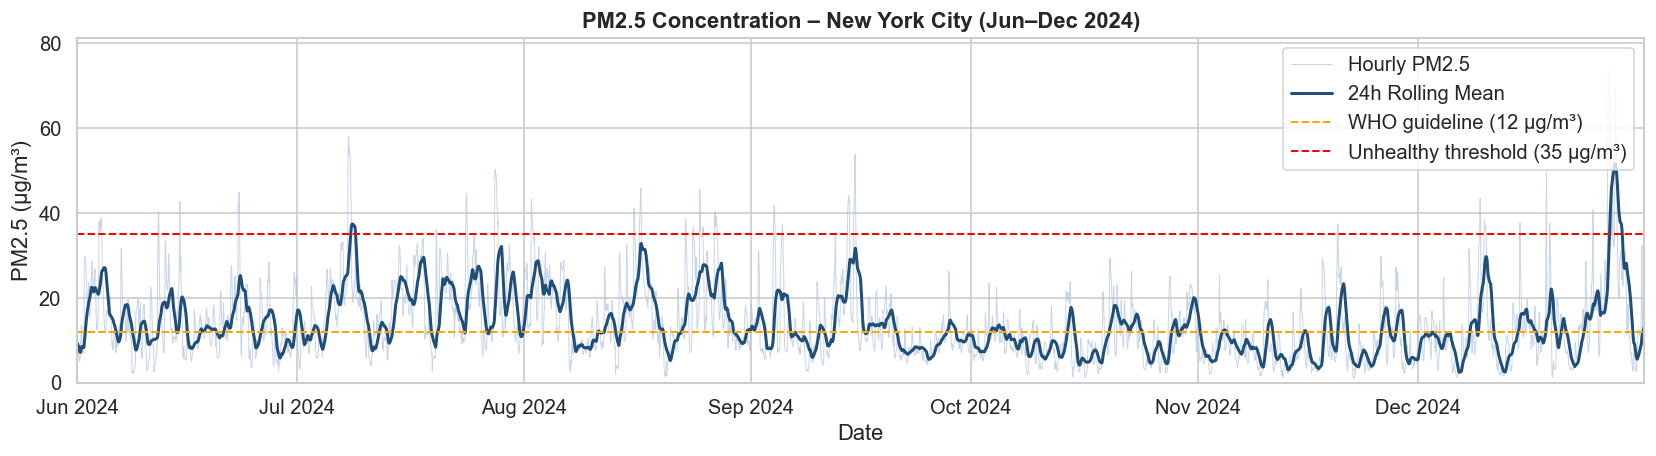

In [26]:
# ── Plot 1: PM2.5 time series with 24h rolling average ──────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df["datetime"], df["pm2_5"],
        color="#b0c4de", linewidth=0.6, alpha=0.7, label="Hourly PM2.5")

rolling = df.set_index("datetime")["pm2_5"].rolling("24h").mean()
ax.plot(rolling.index, rolling.values,
        color="#1f4e79", linewidth=1.8, label="24h Rolling Mean")

ax.axhline(12, color="orange", linestyle="--", linewidth=1.2, label="WHO guideline (12 µg/m³)")
ax.axhline(35, color="red",    linestyle="--", linewidth=1.2, label="Unhealthy threshold (35 µg/m³)")

ax.set_title("PM2.5 Concentration – New York City (Jun–Dec 2024)")
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xlim(df["datetime"].min(), df["datetime"].max())
ax.set_ylim(0, df["pm2_5"].max() * 1.1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("data/processed/plot1_pm25_timeseries.png", dpi=150)
plt.show()

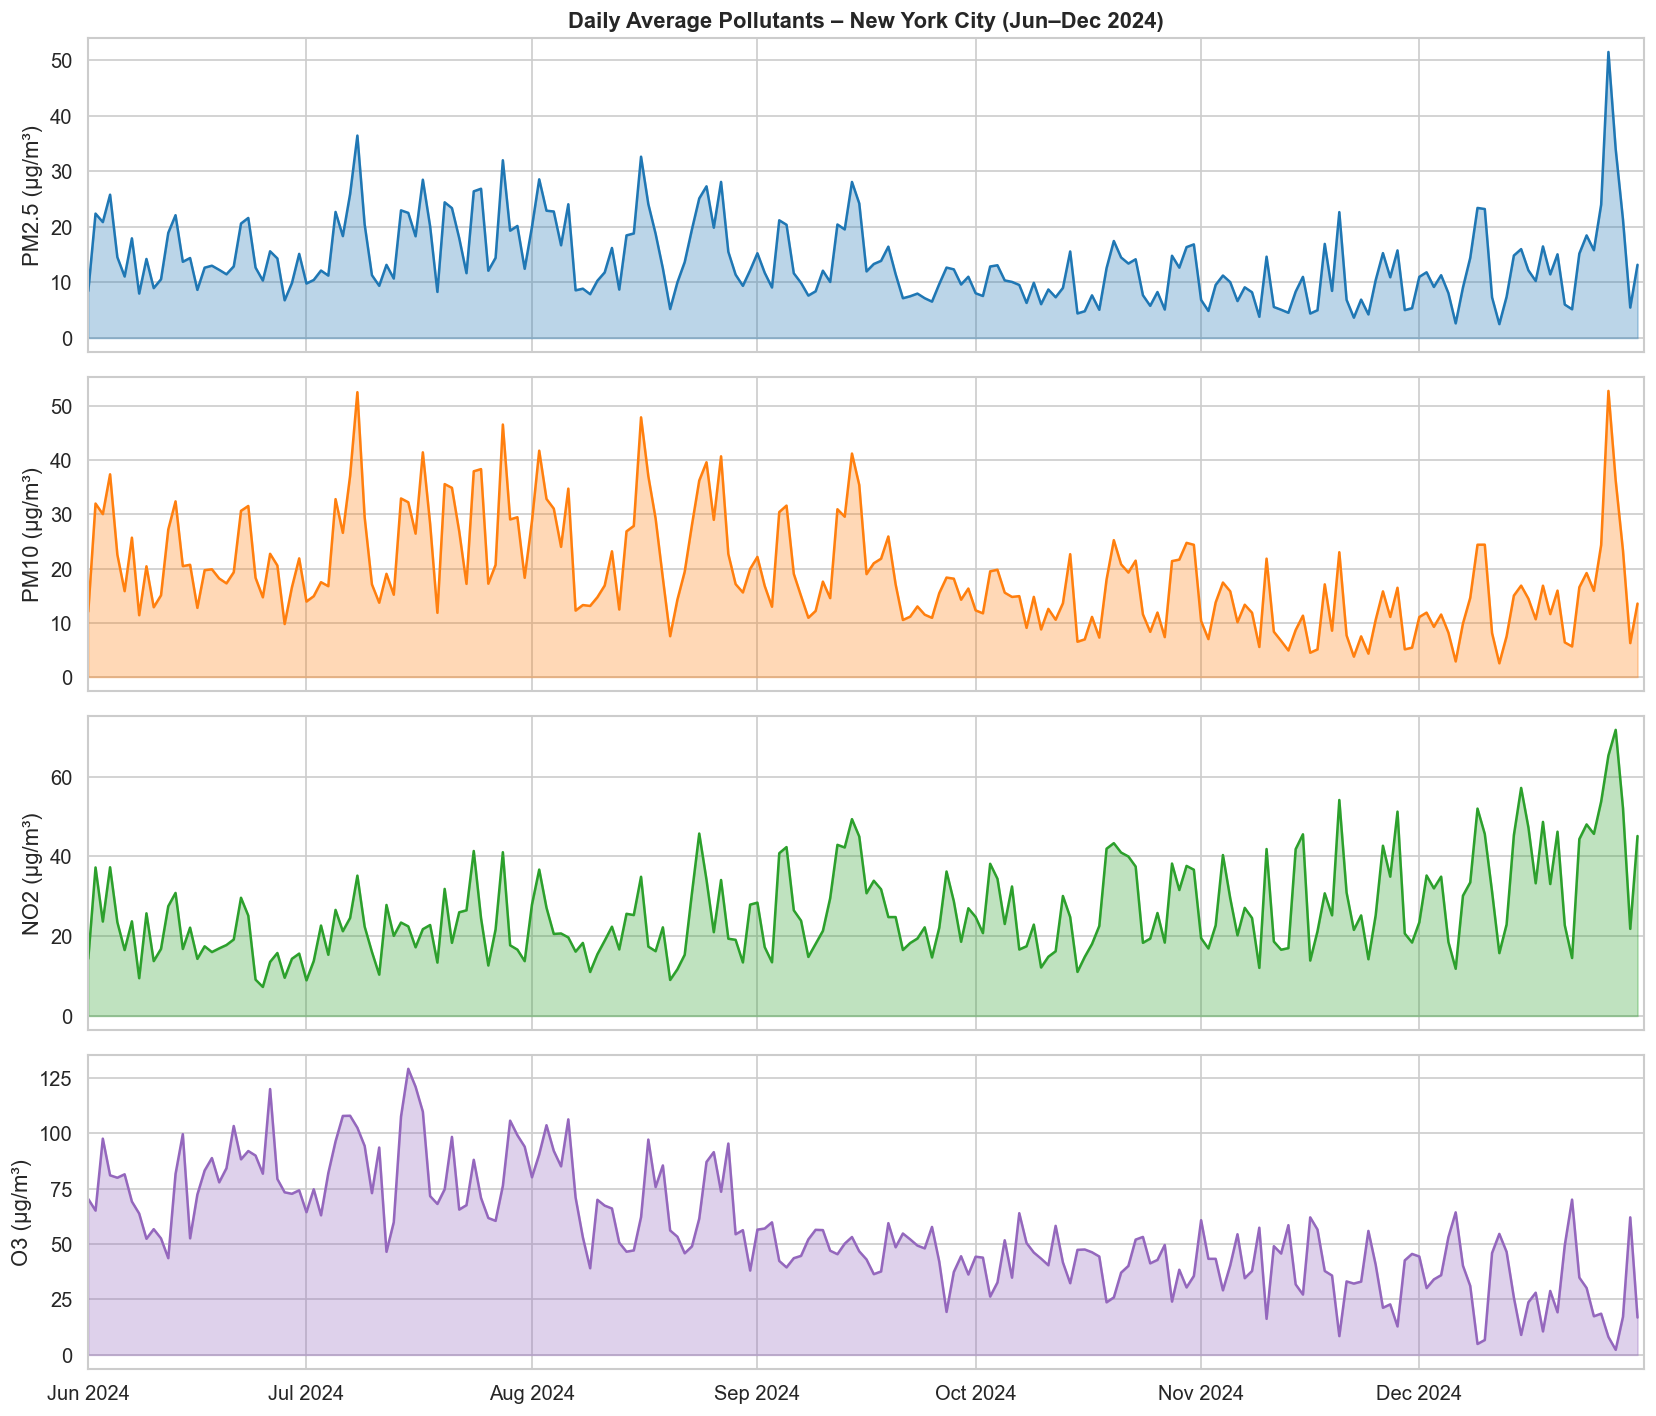

In [27]:
# ── Plot 2: All pollutants over time ────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

pollutants = [
    ("pm2_5",            "PM2.5 (µg/m³)",  "#1f77b4"),
    ("pm10",             "PM10 (µg/m³)",   "#ff7f0e"),
    ("nitrogen_dioxide", "NO2 (µg/m³)",    "#2ca02c"),
    ("ozone",            "O3 (µg/m³)",     "#9467bd"),
]

for ax, (col, label, color) in zip(axes, pollutants):
    daily = df.set_index("datetime")[col].resample("D").mean()
    ax.fill_between(daily.index, daily.values, alpha=0.3, color=color)
    ax.plot(daily.index, daily.values, color=color, linewidth=1.5)
    ax.set_ylabel(label)
    ax.set_xlim(df["datetime"].min(), df["datetime"].max())

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[0].set_title("Daily Average Pollutants – New York City (Jun–Dec 2024)")
plt.tight_layout()
plt.savefig("data/processed/plot2_all_pollutants.png", dpi=150)
plt.show()

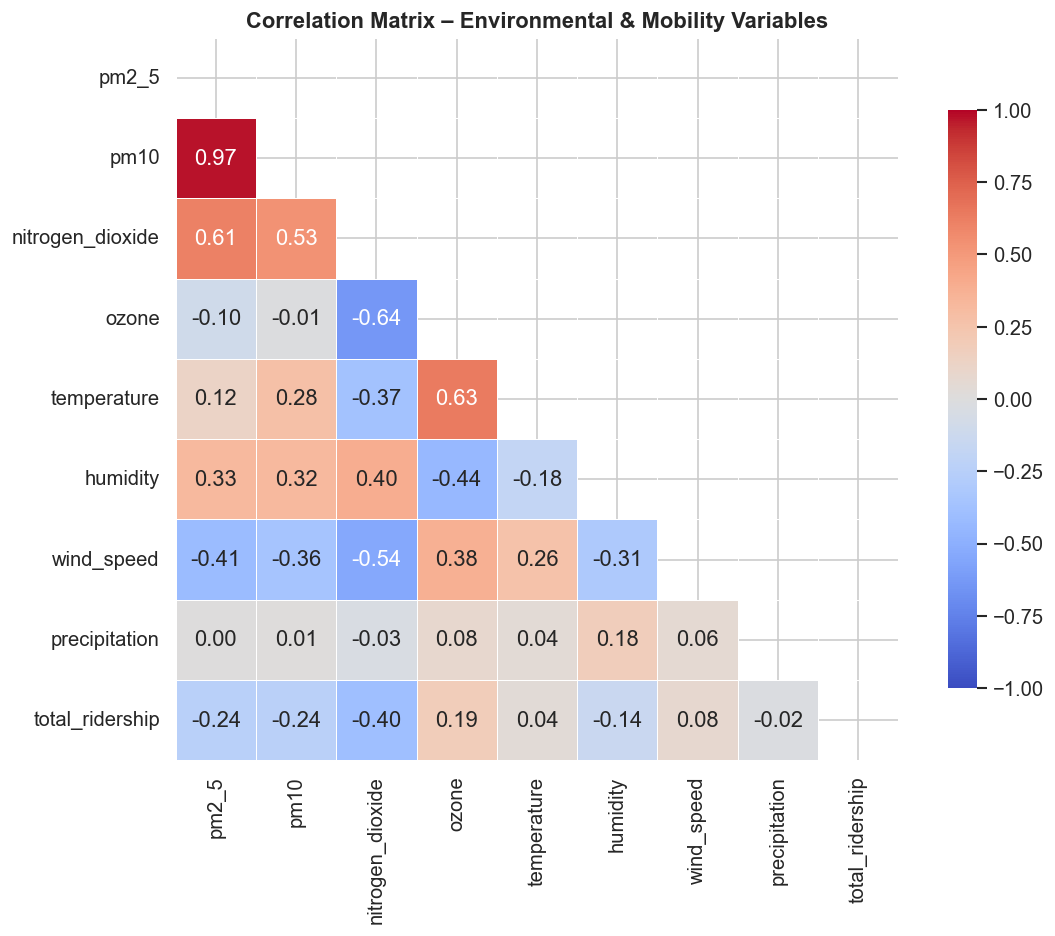

In [28]:
# ── Plot 3: Correlation heatmap ──────────────────────────────────────────────
cols = ["pm2_5", "pm10", "nitrogen_dioxide", "ozone",
        "temperature", "humidity", "wind_speed",
        "precipitation", "total_ridership"]

corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show only lower triangle

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})

ax.set_title("Correlation Matrix – Environmental & Mobility Variables")
plt.tight_layout()
plt.savefig("data/processed/plot3_correlation.png", dpi=150)
plt.show()

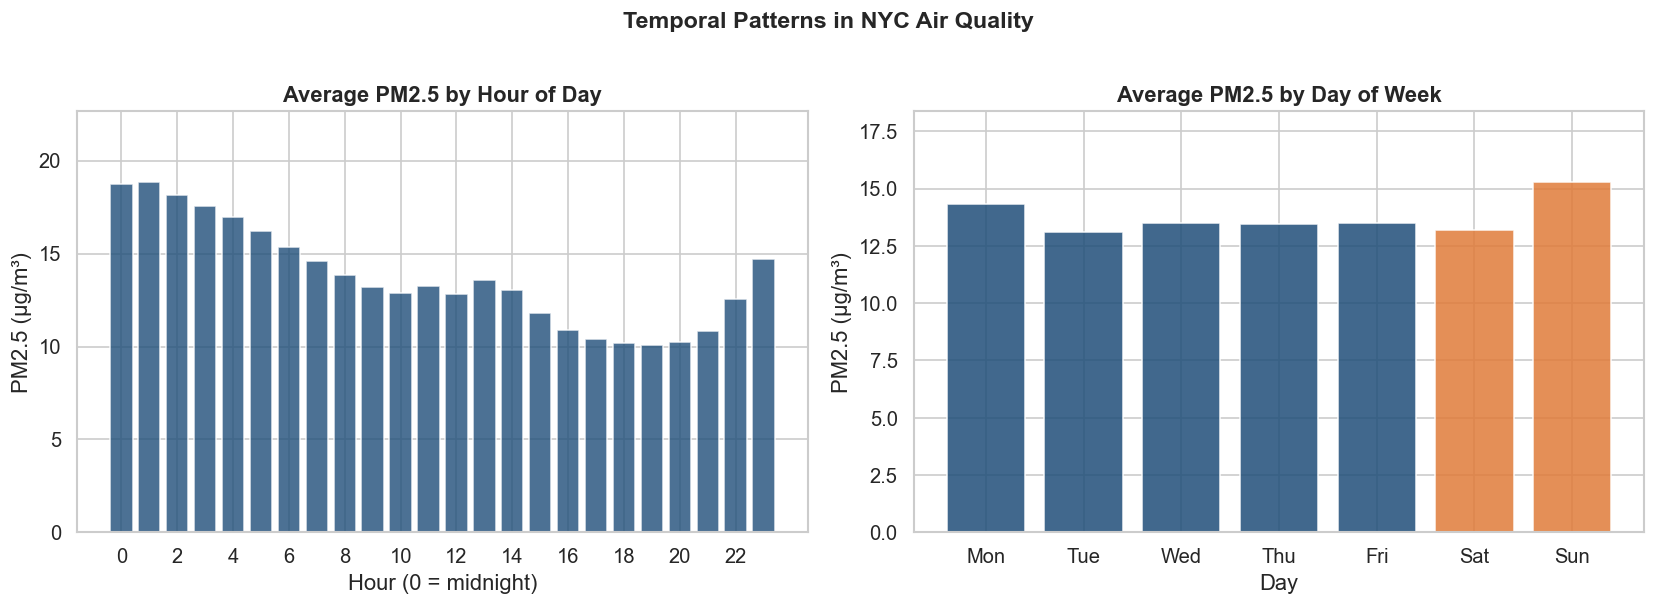

In [29]:
# ── Plot 4: Hourly and weekly patterns ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: average PM2.5 by hour of day
hourly = df.groupby("hour")["pm2_5"].mean()
axes[0].bar(hourly.index, hourly.values, color="#1f4e79", alpha=0.8, edgecolor="white")
axes[0].set_title("Average PM2.5 by Hour of Day")
axes[0].set_xlabel("Hour (0 = midnight)")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_ylim(0, hourly.max() * 1.2)

# Right: average PM2.5 by day of week
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekly = df.groupby("day_of_week")["pm2_5"].mean()
colors = ["#1f4e79"] * 5 + ["#e07b39"] * 2   # weekdays blue, weekends orange
axes[1].bar(day_labels, weekly.values, color=colors, alpha=0.85, edgecolor="white")
axes[1].set_title("Average PM2.5 by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_ylim(0, weekly.max() * 1.2)

plt.suptitle("Temporal Patterns in NYC Air Quality", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("data/processed/plot4_patterns.png", dpi=150)
plt.show()

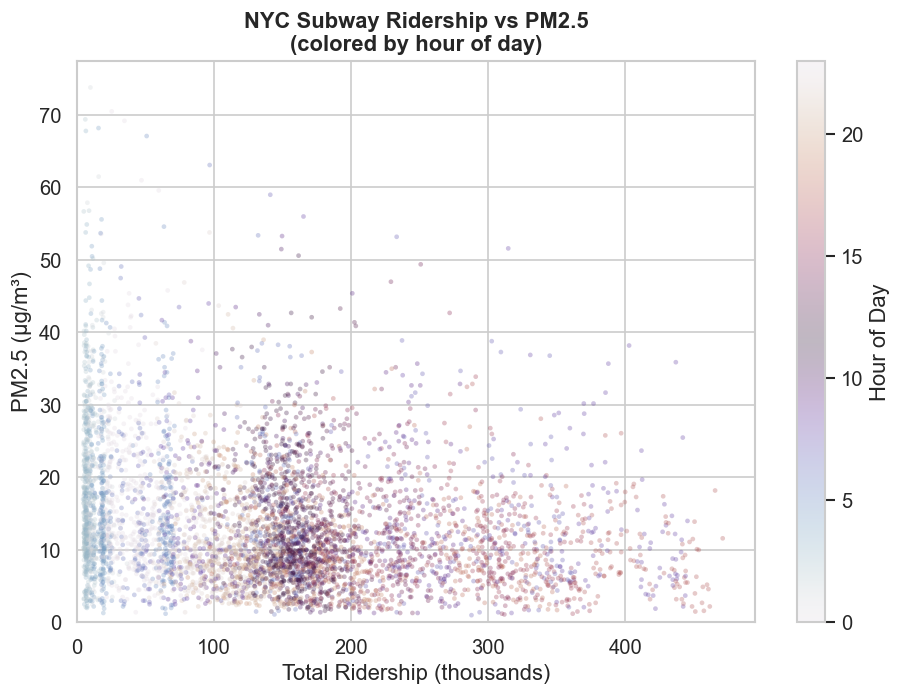

In [30]:
# ── Plot 5: Ridership vs PM2.5 scatter ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(df["total_ridership"] / 1000,
                     df["pm2_5"],
                     c=df["hour"], cmap="twilight",
                     alpha=0.3, s=8, edgecolors="none")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Hour of Day")

ax.set_title("NYC Subway Ridership vs PM2.5\n(colored by hour of day)")
ax.set_xlabel("Total Ridership (thousands)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xlim(0, df["total_ridership"].max() / 1000 * 1.05)
ax.set_ylim(0, df["pm2_5"].max() * 1.05)

plt.tight_layout()
plt.savefig("data/processed/plot5_ridership_vs_pm25.png", dpi=150)
plt.show()

### Key findings from EDA

- **PM2.5 peaks** occasionally exceed the 35 µg/m³ unhealthy threshold,
  with the 24h rolling average generally staying below the WHO guideline of 12 µg/m³.
- **Ozone** shows a clear seasonal pattern, higher in summer months.
- **Correlation**: PM2.5 and PM10 are strongly correlated (expected).
  Wind speed shows a negative correlation with pollutants — higher wind disperses pollution.
- **Hourly pattern**: PM2.5 peaks around rush hours (8–9am, 6–7pm).
- **Weekly pattern**: slightly higher PM2.5 on weekdays vs weekends,
  consistent with traffic and industrial activity.
- **Ridership vs PM2.5**: weak positive correlation, suggesting mobility
  contributes marginally to pollution but is not the dominant factor.

## Task 4 – Time Series Forecasting

We forecast future PM2.5 levels using SARIMA (Seasonal ARIMA).
SARIMA is well suited for hourly environmental data because it captures:
- Trends over time
- Daily seasonality (24h cycles)
- The influence of past values on future ones

To keep computation feasible, we work on **daily averages** of PM2.5.

Time series length : 214 days
Period             : 2024-06-01 → 2024-12-31
Mean PM2.5         : 13.78 µg/m³
Missing days       : 0


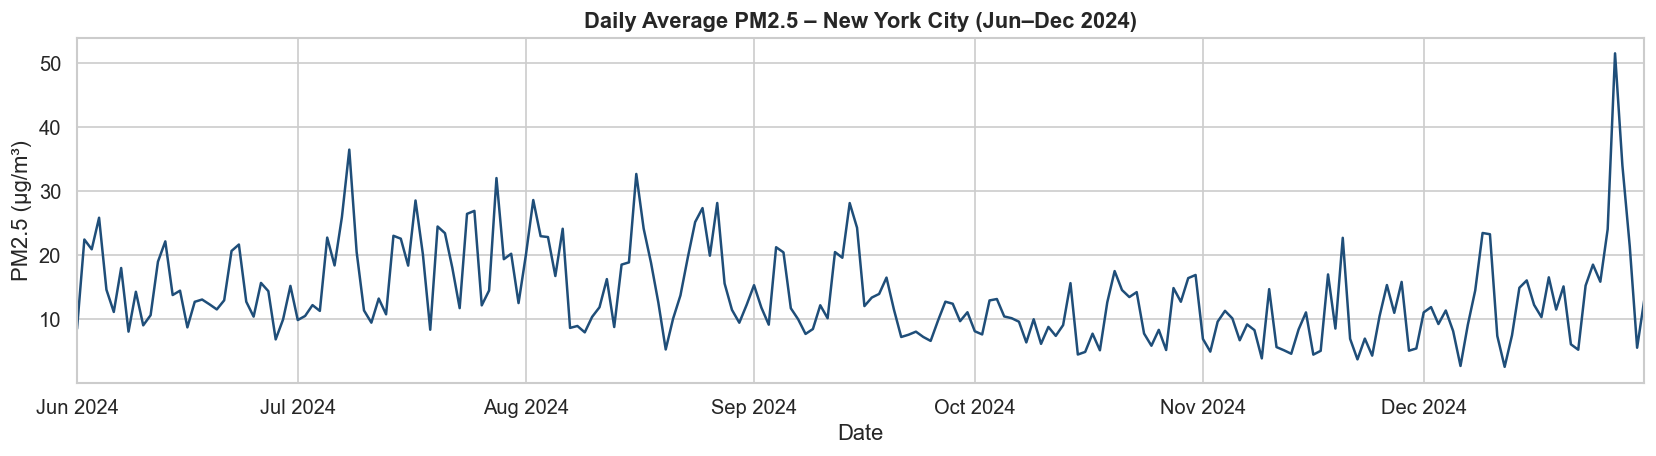

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

# Load unified dataset
df = pd.read_csv("data/processed/nyc_unified.csv", parse_dates=["datetime"])

# Resample to daily average PM2.5
ts = (df.set_index("datetime")["pm2_5"]
        .resample("D")
        .mean()
        .rename("pm2_5"))

print(f"Time series length : {len(ts)} days")
print(f"Period             : {ts.index[0].date()} → {ts.index[-1].date()}")
print(f"Mean PM2.5         : {ts.mean():.2f} µg/m³")
print(f"Missing days       : {ts.isna().sum()}")

# Quick plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ts.index, ts.values, color="#1f4e79", linewidth=1.5)
ax.set_title("Daily Average PM2.5 – New York City (Jun–Dec 2024)")
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xlim(ts.index[0], ts.index[-1])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.savefig("data/processed/plot6_daily_pm25.png", dpi=150)
plt.show()

Train: 184 days (2024-06-01 → 2024-12-01)
Test : 30  days (2024-12-02  → 2024-12-31)


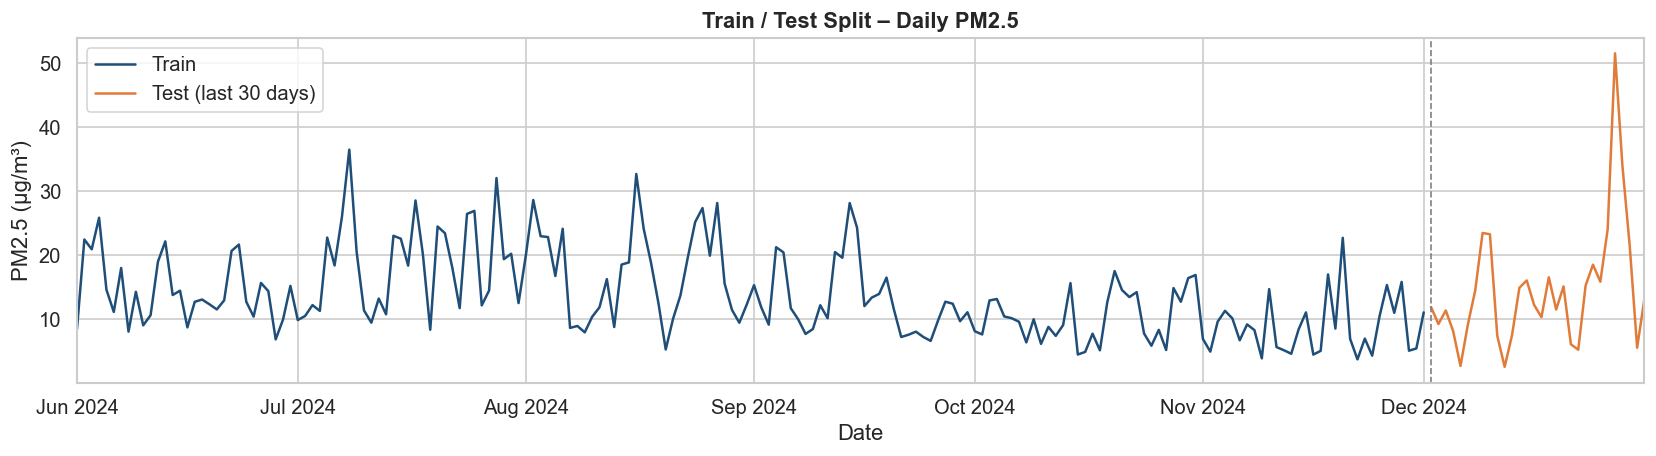

In [35]:
# ── Split: last 30 days = test, rest = train ─────────────────────────────────
TEST_DAYS = 30

train = ts.iloc[:-TEST_DAYS]
test  = ts.iloc[-TEST_DAYS:]

print(f"Train: {len(train)} days ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test : {len(test)}  days ({test.index[0].date()}  → {test.index[-1].date()})")

# Visualize the split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train.values, color="#1f4e79", linewidth=1.5, label="Train")
ax.plot(test.index,  test.values,  color="#e07b39", linewidth=1.5, label="Test (last 30 days)")
ax.axvline(test.index[0], color="gray", linestyle="--", linewidth=1)
ax.set_title("Train / Test Split – Daily PM2.5")
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xlim(ts.index[0], ts.index[-1])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend()
plt.tight_layout()
plt.savefig("data/processed/plot7_train_test_split.png", dpi=150)
plt.show()

In [36]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA(1,1,1)(1,0,1,7):
#   (1,1,1)   = non-seasonal: AR=1, differencing=1, MA=1
#   (1,0,1,7) = weekly seasonality: SAR=1, no seasonal diff, SMA=1, period=7
print("Fitting SARIMA model (this may take ~30 seconds)...")

model = SARIMAX(train,
                order=(1, 1, 1),
                seasonal_order=(1, 0, 1, 7),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit(disp=False)

print(result.summary().tables[0])
print("\nAIC:", round(result.aic, 2))
print("BIC:", round(result.bic, 2))

Fitting SARIMA model (this may take ~30 seconds)...
                                     SARIMAX Results                                     
Dep. Variable:                             pm2_5   No. Observations:                  184
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood                -542.394
Date:                           Thu, 26 Mar 2026   AIC                           1094.788
Time:                                   16:59:52   BIC                           1110.583
Sample:                               06-01-2024   HQIC                          1101.195
                                    - 12-01-2024                                         
Covariance Type:                             opg                                         

AIC: 1094.79
BIC: 1110.58


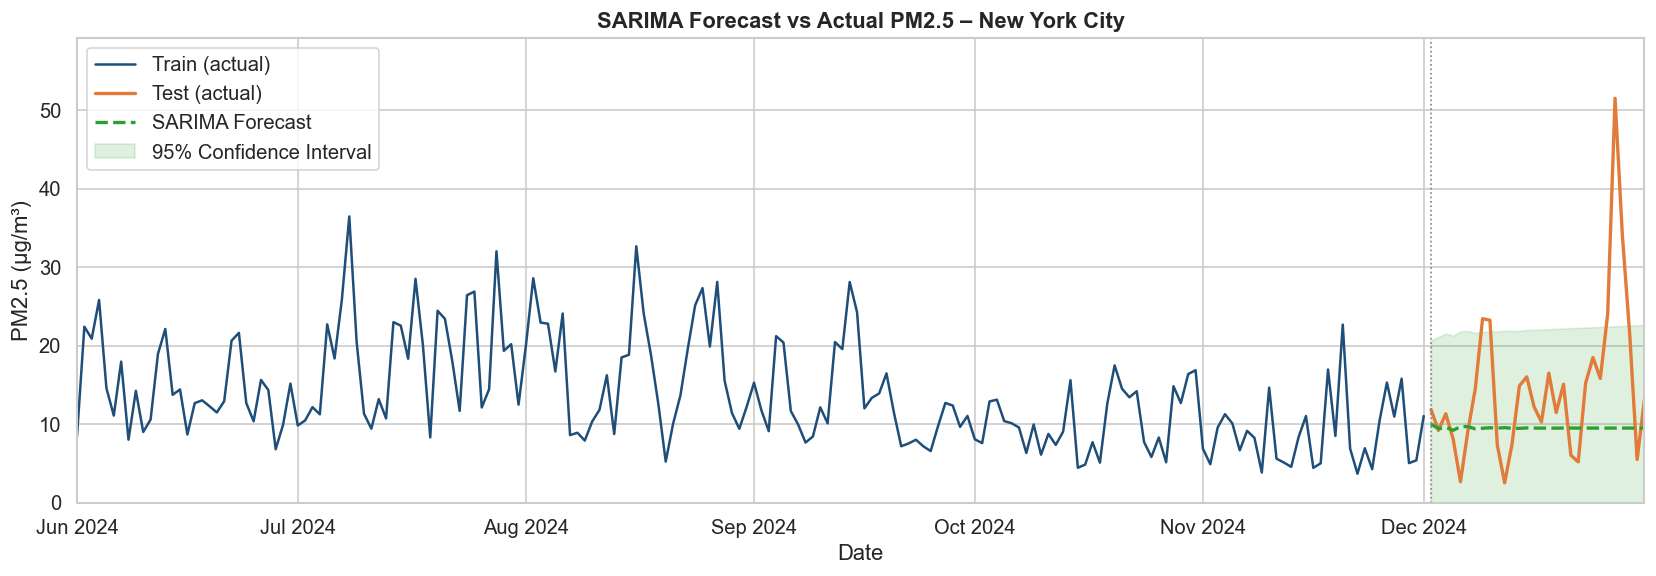

In [37]:
# ── Forecast on test set ──────────────────────────────────────────────────────
forecast_obj = result.get_forecast(steps=TEST_DAYS)
forecast     = forecast_obj.predicted_mean
conf_int     = forecast_obj.conf_int(alpha=0.05)   # 95% confidence interval

# Plot forecast vs actual
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train.index, train.values,
        color="#1f4e79", linewidth=1.5, label="Train (actual)")
ax.plot(test.index, test.values,
        color="#e07b39", linewidth=2, label="Test (actual)")
ax.plot(forecast.index, forecast.values,
        color="#2ca02c", linewidth=2, linestyle="--", label="SARIMA Forecast")
ax.fill_between(conf_int.index,
                conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                color="#2ca02c", alpha=0.15, label="95% Confidence Interval")

ax.axvline(test.index[0], color="gray", linestyle=":", linewidth=1)
ax.set_title("SARIMA Forecast vs Actual PM2.5 – New York City")
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xlim(ts.index[0], ts.index[-1])
ax.set_ylim(0, max(ts.max(), forecast.max()) * 1.15)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend()
plt.tight_layout()
plt.savefig("data/processed/plot8_sarima_forecast.png", dpi=150)
plt.show()

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── Metrics ───────────────────────────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(test.values, forecast.values))
mae  = mean_absolute_error(test.values, forecast.values)
mape = np.mean(np.abs((test.values - forecast.values) / test.values)) * 100

print("=== Task 5 – Model Evaluation ===\n")
print(f"RMSE : {rmse:.2f} µg/m³")
print(f"MAE  : {mae:.2f} µg/m³")
print(f"MAPE : {mape:.1f}%")
print(f"\nBaseline (predict mean): RMSE = {np.sqrt(mean_squared_error(test.values, [train.mean()]*TEST_DAYS)):.2f}")

=== Task 5 – Model Evaluation ===

RMSE : 10.98 µg/m³
MAE  : 7.19 µg/m³
MAPE : 55.1%

Baseline (predict mean): RMSE = 9.77


## Task 5 – Evaluation and Interpretation

### Results
| Metric | Value |
|--------|-------|
| RMSE   | 10.98 µg/m³ |
| MAE    | 7.19 µg/m³  |
| MAPE   | 55.1%       |

### Discussion
The MAE of 7.19 µg/m³ indicates that on average the model errs by
about 7 µg/m³ — acceptable given that PM2.5 ranges from 1 to 73 µg/m³
in our dataset. The high MAPE (55.1%) is partly explained by hours where
PM2.5 approaches zero, making percentage errors disproportionately large.

SARIMA captures the weekly seasonality well but struggles with
sudden spikes (e.g. the late-December pollution event visible in the
test set), which are caused by external factors not present in the model.

### Limitations
- Univariate model: weather and traffic are not used as inputs.
  A SARIMAX with wind speed and humidity as exogenous variables
  would likely reduce RMSE significantly.
- Only 7 months of training data — not enough to learn annual seasonality.
- PM2.5 spikes from events like wildfires or temperature inversions
  cannot be predicted from historical patterns alone.

### Possible improvements
- Add exogenous variables (wind speed, humidity) via SARIMAX
- Use Facebook Prophet for automatic seasonality detection
- Try LSTM neural networks for non-linear temporal patterns